In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
metrics_json_paths = glob('./logs/finetune_20250704/*/*/*/*/*/*/*/assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 55 metrics JSON files.


In [9]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    # for i, part in enumerate(split_path_parts):
        # print(f'Part {i}: {part}')
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[6] == 'frozenencoder_true'
    n_train = split_path_parts[7]
    fold = split_path_parts[8].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
18,0.872005,0.872005,0.872005,0.872005,0.773058,0.776594,1.588889,0.029987,0.751115,0.783126,...,0.870841,0.872005,0.781198,1.588889,0.029987,unet,byol,False,500,2
38,0.869725,0.869725,0.869725,0.869725,0.769481,0.772806,1.538013,0.026472,0.747704,0.785791,...,0.870655,0.869725,0.777918,1.538013,0.026472,unet,imagenet,True,750,1
35,0.865285,0.865285,0.865285,0.865285,0.762558,0.765488,1.547037,0.027277,0.742984,0.783181,...,0.869710,0.865285,0.772312,1.547037,0.027277,unet,imagenet,True,750,4
31,0.867765,0.867765,0.867765,0.867765,0.766418,0.768264,1.557551,0.027518,0.742130,0.789499,...,0.868578,0.867765,0.774052,1.557551,0.027518,unet,imagenet,True,500,2
34,0.868245,0.868245,0.868245,0.868245,0.767167,0.769464,1.573016,0.028472,0.742022,0.784093,...,0.869260,0.868245,0.775671,1.573016,0.028472,unet,imagenet,True,500,1
52,0.868165,0.868165,0.868165,0.868165,0.767042,0.771546,1.566007,0.028535,0.741875,0.784370,...,0.869905,0.868165,0.777732,1.566007,0.028535,unet,imagenet,False,750,1
23,0.869525,0.869525,0.869525,0.869525,0.769168,0.772638,1.556002,0.028053,0.741360,0.779088,...,0.871532,0.869525,0.778017,1.556002,0.028053,unet,byol,False,750,3
24,0.860246,0.860246,0.860246,0.860246,0.754764,0.759291,1.545584,0.028288,0.741127,0.761884,...,0.863800,0.860246,0.767461,1.545584,0.028288,unet,byol,False,750,2
36,0.865885,0.865885,0.865885,0.865885,0.763490,0.766375,1.529540,0.026217,0.739070,0.776842,...,0.869524,0.865885,0.772537,1.529540,0.026217,unet,imagenet,True,750,3
33,0.865685,0.865685,0.865685,0.865685,0.763179,0.765371,1.543705,0.026903,0.738472,0.775120,...,0.865639,0.865685,0.772338,1.543705,0.026903,unet,imagenet,True,500,6


In [ ]:
metrics_df.loc[]

In [10]:
metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).count()

accuracy  f1_score  \
model         pretrain_method frozen_encoder n_train                       
deeplabv3plus byol            False          750             1         1   
              imagenet        False          750             1         1   
unet          byol            False          250             3         3   
                                             500             6         6   
                                             750             4         4   
                              True           250             3         3   
                                             500             6         6   
                                             750             4         4   
              imagenet        False          250             4         4   
                                             500             6         6   
                                             750             4         4   
                              True           250             3         3   
                                             500             6         6   
                                             750             4         4   

                                                      precision  recall  \
model         pretrain_method frozen_encoder n_train                      
deeplabv3plus byol            False          750              1       1   
              imagenet        False          750              1       1   
unet          byol            False          250              3       3   
                                             500              6       6   
                                             750              4       4   
                              True           250              3       3   
                                             500              6       6   
                                             750              4       4   
              imagenet        False          250              4       4   
                                             500              6       6   
                                             750              4       4   
                              True           250              3       3   
                                             500              6       6   
                                             750              4       4   

                                                      jaccard  kappa  \
model         pretrain_method frozen_encoder n_train                   
deeplabv3plus byol            False          750            1      1   
              imagenet        False          750            1      1   
unet          byol            False          250            3      3   
                                             500            6      6   
                                             750            4      4   
                              True           250            3      3   
                                             500            6      6   
                                             750            4      4   
              imagenet        False          250            4      4   
                                             500            6      6   
                                             750            4      4   
                              True           250            3      3   
                                             500            6      6   
                                             750            4      4   

                                                      cross_entropy  \
model         pretrain_method frozen_encoder n_train                  
deeplabv3plus byol            False          750                  1   
              imagenet        False          750                  1   
unet          byol            False          250                  3   
                                             500                  6   
                                             750         

IndexError: list index out of range

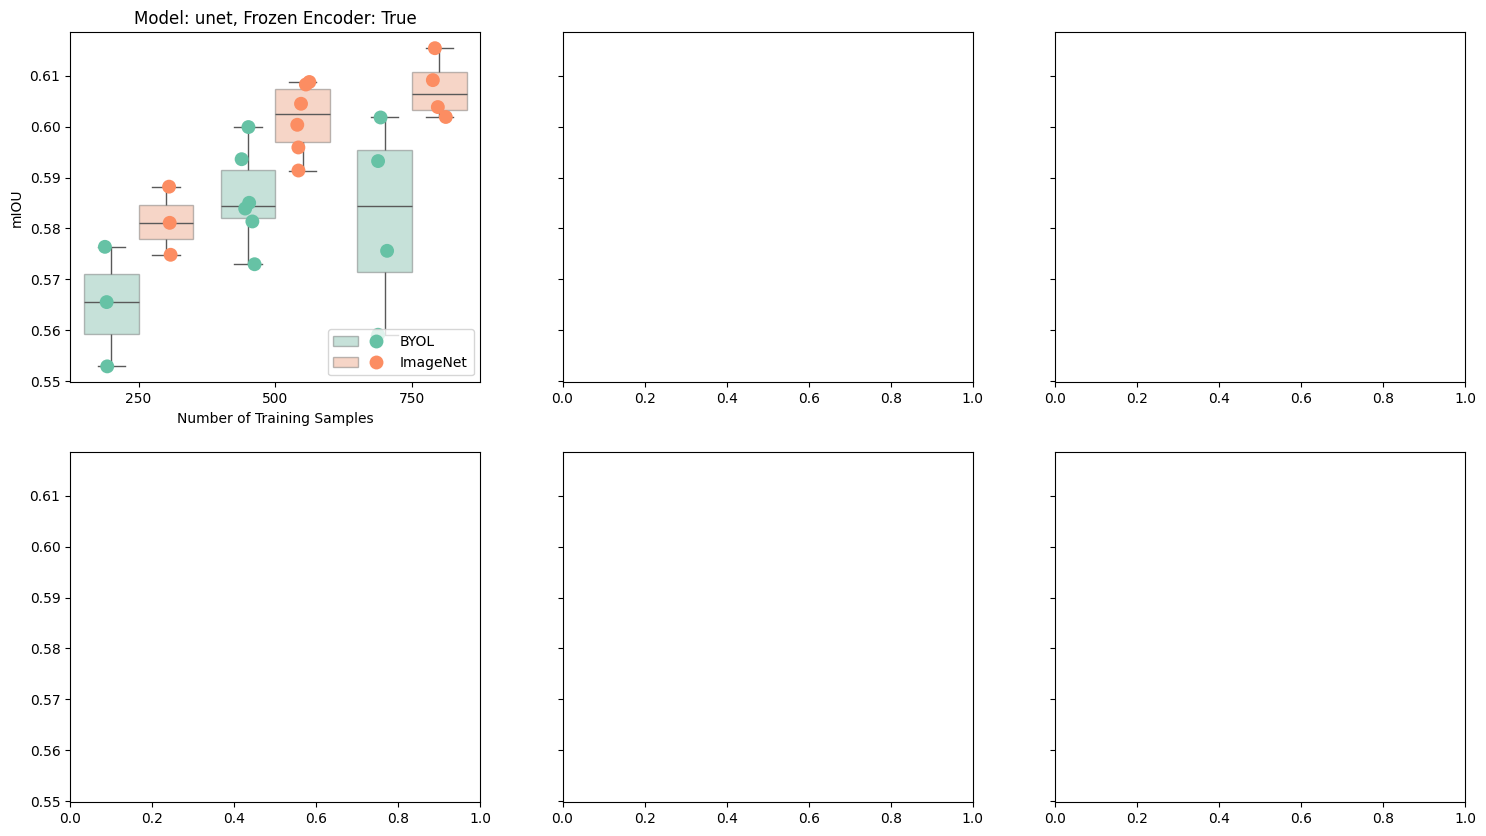

In [ ]:
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
    # print(i, model)
    for j, model in enumerate(metrics_df['model'].unique()):
        # metrics_df['model']
        # print(j, frozen_encoder)
        subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
        # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
        # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
        # sns.pointplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j], dodge=True, errorbar='iqr')
        sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
        sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], jitter=True, dodge=True, palette='Set2', size=10)
        handles, labels = ax[i, j].get_legend_handles_labels()
        # ax[i, j].legend(handles=[(handles[0], handles[2]), (handles[1], handles[3])],
                # labels=['BYOL', 'ImageNet'],
                # loc='lower right', handlelength=4,
                handler_map={tuple: HandlerTuple(ndivide=None)})
        ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
        ax[i, j].set_xlabel('Number of Training Samples')
        ax[i, j].set_ylabel('mIOU')

In [18]:
metrics_reduced_df = metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).agg({
    'macro_f1_score': ['mean', 'std'],
    'macro_jaccard': ['mean', 'std'],
    'f1_score': ['mean', 'std'],
    # 'precision': ['mean', 'std'],
    # 'recall': ['mean', 'std']
}).reset_index()
# Optionally, flatten the MultiIndex columns
metrics_reduced_df.columns = ['_'.join(col).strip('_') for col in metrics_reduced_df.columns.values]
metrics_reduced_df.sort_values(by='macro_jaccard_mean', ascending=False)

,model,pretrain_method,frozen_encoder,n_train,macro_f1_score_mean,macro_f1_score_std,macro_jaccard_mean,macro_jaccard_std,f1_score_mean,f1_score_std
13,unet,imagenet,True,750,0.741142,0.005502,0.607578,0.006057,0.866975,0.001967
4,unet,byol,False,750,0.738125,0.004121,0.603794,0.005185,0.865285,0.004878
12,unet,imagenet,True,500,0.736325,0.005620,0.601536,0.006969,0.864699,0.003541
10,unet,imagenet,False,750,0.730317,0.008452,0.594922,0.008857,0.860936,0.005279
3,unet,byol,False,500,0.729159,0.013377,0.594152,0.015333,0.860992,0.006579
6,unet,byol,True,500,0.722210,0.007617,0.586133,0.009468,0.854852,0.008011
9,unet,imagenet,False,500,0.720589,0.009795,0.583808,0.010716,0.859886,0.003730
7,unet,byol,True,750,0.718124,0.018996,0.582436,0.018997,0.858136,0.006062
1,deeplabv3plus,imagenet,False,750,0.718379,NaN,0.581809,NaN,0.856446,NaN
11,unet,imagenet,True,250,0.719331,0.004855,0.581377,0.006697,0.860246,0.004554


In [20]:
# group 
import scipy.stats as stats

# Choose the metric to compare
metric = 'macro_jaccard'

# Store results
test_results = []

# Loop over groups
for (model, frozen_encoder, n_train), group in metrics_df.groupby(['model', 'frozen_encoder', 'n_train']):
    # Pivot so each method's results are columns, indexed by fold
    pivot = group.pivot(index='fold', columns='pretrain_method', values=metric)
    # Only test if both methods are present and have at least 2 folds
    if {'byol', 'imagenet'}.issubset(pivot.columns) and len(pivot) > 1:
        # Drop NaNs (in case some folds are missing)
        byol = pivot['byol'].dropna()
        imagenet = pivot['imagenet'].dropna()
        # Align folds
        common_folds = byol.index.intersection(imagenet.index)
        if len(common_folds) > 1:
            stat, p = stats.wilcoxon(byol.loc[common_folds], imagenet.loc[common_folds])
            test_results.append({
                'model': model,
                'frozen_encoder': frozen_encoder,
                'n_train': n_train,
                'statistic': stat,
                'p_value': p,
                'byol_mean': byol.loc[common_folds].mean(),
                'imagenet_mean': imagenet.loc[common_folds].mean(),
                'n_folds': len(common_folds)
            })

# Show results as DataFrame
test_results_df = pd.DataFrame(test_results)
display(test_results_df.sort_values('p_value'))

,model,frozen_encoder,n_train,statistic,p_value,byol_mean,imagenet_mean,n_folds
1,unet,False,500,0.0,0.03125,0.594152,0.583808,6
4,unet,True,500,0.0,0.03125,0.586133,0.601536,6
5,unet,True,750,0.0,0.12500,0.582436,0.607578,4
0,unet,False,250,0.0,0.25000,0.575095,0.562247,3
2,unet,False,750,1.0,0.25000,0.603794,0.594922,4
3,unet,True,250,0.0,0.25000,0.564934,0.581377,3


In [19]:
metrics_df.sort_values(by='macro_jaccard', ascending=False)['macro_jaccard'].head()

18    0.619082
38    0.615420
23    0.609345
35    0.609144
34    0.608777
Name: macro_jaccard, dtype: float64